Laptop Price Predictor

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# Dataset
data = {
    'ram_gb': [4, 8, 4, 16, 8, 8, 4, 16, 8, 16,
               4, 8, 4, 16, 8, 8, 4, 16, 8, 16,
               4, 8, 4, 16, 8, 8, 4, 16, 8, 16],

    'storage_gb': [256, 512, 128, 512, 256, 512, 256, 1024, 256, 512,
                   128, 512, 256, 1024, 256, 512, 128, 512, 256, 1024,
                   256, 512, 128, 512, 256, 512, 256, 1024, 256, 512],

    'processor_ghz': [2.1, 2.8, 1.8, 3.2, 2.4, 3.0, 2.0, 3.5, 2.6, 3.0,
                      1.6, 2.8, 2.2, 3.4, 2.5, 2.9, 1.9, 3.1, 2.3, 3.6,
                      2.0, 2.7, 1.7, 3.3, 2.4, 3.0, 2.1, 3.5, 2.6, 3.2],

    'price_inr': [28000, 45000, 22000, 72000, 38000, 52000, 26000, 95000, 42000, 68000,
                  20000, 48000, 29000, 88000, 40000, 50000, 23000, 70000, 36000, 98000,
                  25000, 46000, 21000, 75000, 39000, 53000, 27000, 92000, 43000, 73000]
}

In [4]:
df = pd.DataFrame(data)
df.head()

,ram_gb,storage_gb,processor_ghz,price_inr
0,4,256,2.1,28000
1,8,512,2.8,45000
2,4,128,1.8,22000
3,16,512,3.2,72000
4,8,256,2.4,38000


In [5]:
df.describe()

,ram_gb,storage_gb,processor_ghz,price_inr
count,30.000000,30.000000,30.000000,30.000000
mean,9.200000,435.200000,2.640000,49466.666667
std,4.830935,274.323544,0.582267,23875.731920
min,4.000000,128.000000,1.600000,20000.000000
25%,4.000000,256.000000,2.125000,28250.000000
50%,8.000000,384.000000,2.650000,44000.000000
75%,16.000000,512.000000,3.075000,69500.000000
max,16.000000,1024.000000,3.600000,98000.000000


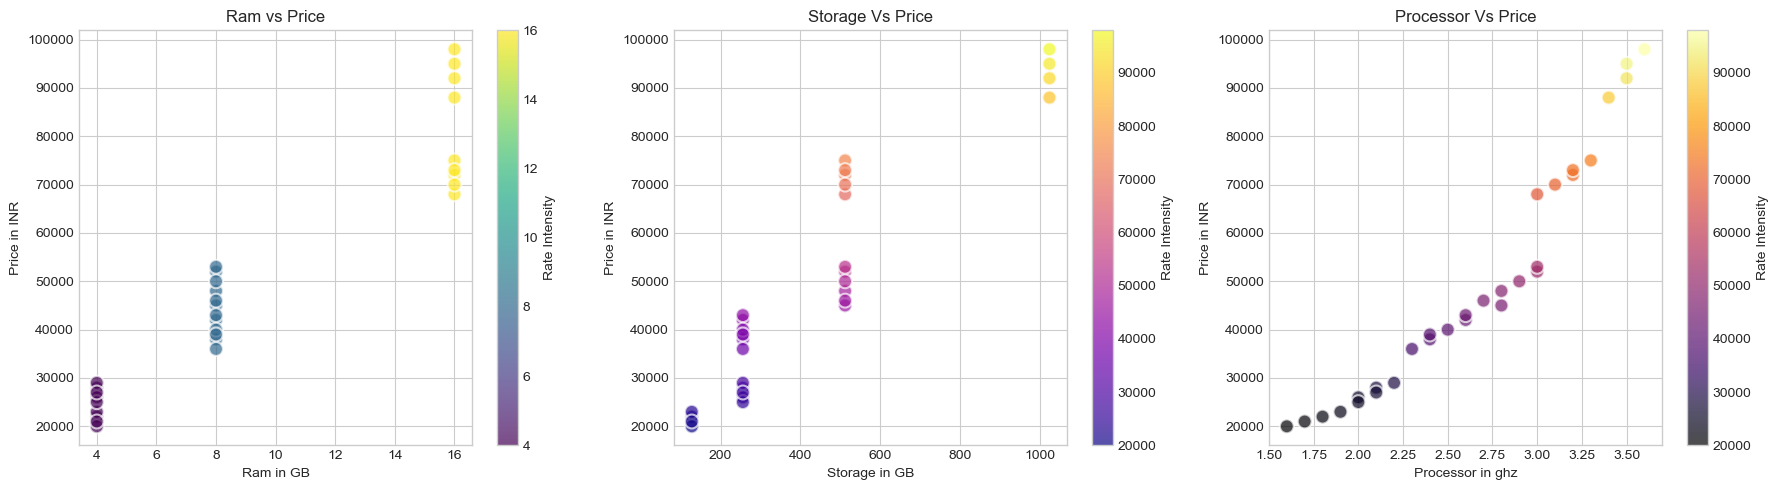

In [6]:
# visualize the data
plt.style.use('seaborn-v0_8-whitegrid')
fig, axis = plt.subplots(1,3, figsize=(18,5))
scatter1 = axis[0].scatter(df['ram_gb'], df['price_inr'],
                           c =df['ram_gb'], cmap='viridis', s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
axis[0].set_xlabel('Ram in GB')
axis[0].set_ylabel('Price in INR')
axis[0].set_title('Ram vs Price')
plt.colorbar(scatter1, ax=axis[0], label='Rate Intensity')

scatter2 = axis[1].scatter(df['storage_gb'], df['price_inr'],
                           c = df['price_inr'], cmap='plasma', s=100, alpha =0.7, edgecolors='white',linewidth=1.5)
axis[1].set_xlabel('Storage in GB')
axis[1].set_ylabel('Price in INR')
axis[1].set_title('Storage Vs Price')
plt.colorbar(scatter2, ax=axis[1], label='Rate Intensity')

scatter3 = axis[2].scatter(df['processor_ghz'], df['price_inr'],
                           c = df['price_inr'], cmap='inferno', s=100, alpha =0.7, edgecolors='white',linewidth=1.5)
axis[2].set_xlabel('Processor in ghz')
axis[2].set_ylabel('Price in INR')
axis[2].set_title('Processor Vs Price')
plt.colorbar(scatter3, ax=axis[2], label='Rate Intensity')

plt.tight_layout()
plt.show()

In [7]:
X = df[['ram_gb','storage_gb','processor_ghz']]
y = df['price_inr']

In [8]:
# split the data into training and testing set
random_state = 42
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)


In [9]:
# create model and train it
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
param_1 = model.coef_[0].round()
param_2 = model.coef_[1].round()
param_3 = model.coef_[2].round()
intercept = model.intercept_
param_1,param_2,param_3, intercept
# processor_ghz parameter affects the price most

(np.float64(2313.0),
 np.float64(35.0),
 np.float64(7223.0),
 np.float64(-6558.007474380611))

In [11]:
y_pred = model.predict(X_test)
y_pred

array([20225.99632652, 71686.62292957, 72408.90754956, 20948.28094651,
       26924.76649379, 71686.62292957])

In [12]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted':y_pred.round()})
results

,Actual,Predicted
0,22000,20226.0
1,73000,71687.0
2,75000,72409.0
3,23000,20948.0
4,27000,26925.0
5,72000,71687.0


In [13]:
score = r2_score(y_test, y_pred)
score

0.9956669990572741

In [14]:
new_values = 16, 512, 3.2
new_Fair_Price = model.predict([new_values])
new_Fair_Price
print(f"\n Meera's question — for 16GB RAM, 512GB storage, 3.2 GHz processor, what is a fair price?")
print(f"Predicted Fair Price: {new_Fair_Price[0]:,.0f}")


 Meera's question — for 16GB RAM, 512GB storage, 3.2 GHz processor, what is a fair price?
Predicted Fair Price: 71,687


C:\Users\G.Guna\desktop\ML\heart_disease_project\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
new_values_1 = 8, 512, 2.8
new_Fair_Price_1 = model.predict([new_values_1])
new_Fair_Price_1
print(f"\n Meera's question — for 8GB RAM, 512GB storage, 2.8 GHz processor for 55,000 INR. Is it overpriced?")
print(f"Predicted Fair Price: {new_Fair_Price_1[0]:,.0f}, Its Not overpriced ")


 Meera's question — for 8GB RAM, 512GB storage, 2.8 GHz processor for 55,000 INR. Is it overpriced?
Predicted Fair Price: 50,296, Its Not overpriced 


C:\Users\G.Guna\desktop\ML\heart_disease_project\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
